# Customer Churn Prediction — From Data to Model

This notebook walks through the full ML pipeline:
1. Load data from SQLite
2. Exploratory Data Analysis
3. Feature Engineering
4. Model Training & Evaluation
5. Save the trained model

## 1. Setup & Data Loading

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
conn = sqlite3.connect("../data/ecommerce_ph.db")

customers = pd.read_sql("SELECT * FROM customers", conn)
orders = pd.read_sql("SELECT * FROM orders", conn)
products = pd.read_sql("SELECT * FROM products", conn)

print(f"Customers: {len(customers):,}")
print(f"Orders:    {len(orders):,}")
print(f"Products:  {len(products):,}")

Customers: 96,096
Orders:    99,441
Products:  32,951


In [3]:
orders.head()

,order_id,customer_id,order_date,total_amount,status,days_since_last_order
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,367.74,Delivered,380
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,1343.87,Delivered,84
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,1701.64,Delivered,70
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,685.90,Delivered,332
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,271.89,Delivered,245


## 2. Exploratory Data Analysis

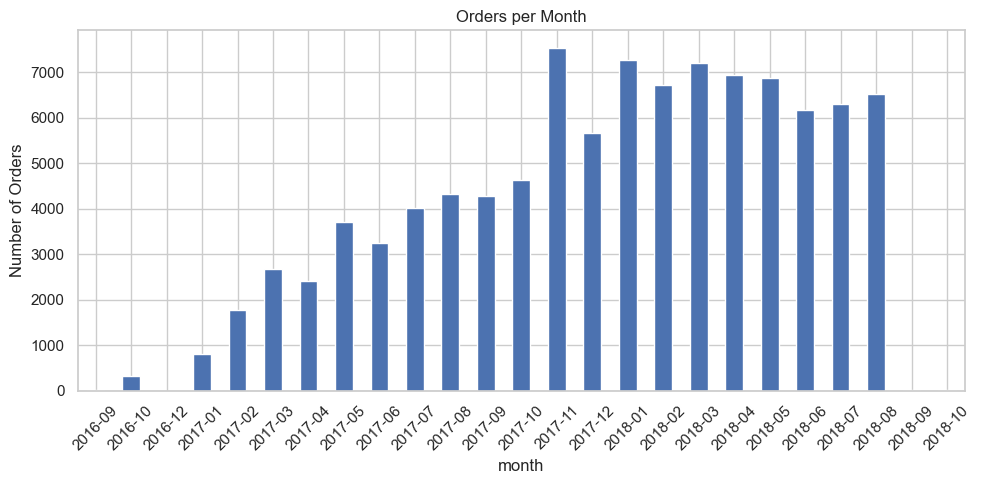

In [4]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["month"] = orders["order_date"].dt.to_period("M")

monthly = orders.groupby("month").size()
monthly.plot(kind="bar", title="Orders per Month", ylabel="Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

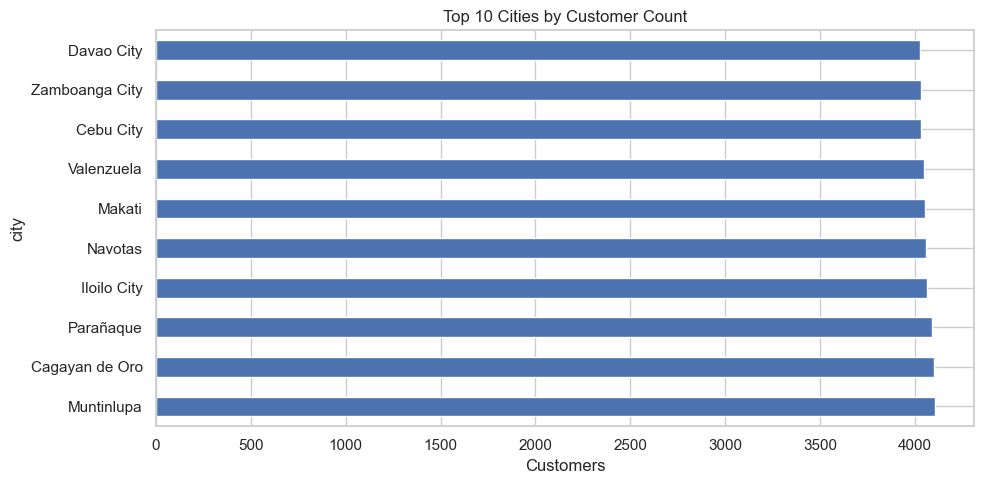

In [5]:
top_cities = customers["city"].value_counts().head(10)
top_cities.plot(kind="barh", title="Top 10 Cities by Customer Count")
plt.xlabel("Customers")
plt.tight_layout()
plt.show()

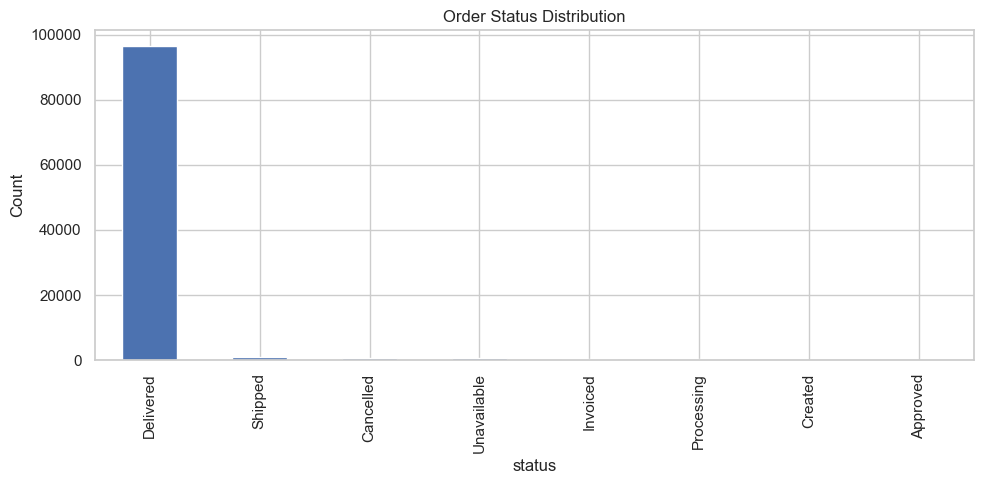

In [6]:
orders["status"].value_counts().plot(
    kind="bar", title="Order Status Distribution", ylabel="Count"
)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

We build a per-customer feature frame for churn prediction.

**Churn definition:** A customer is churned if their last order was more than 90 days ago.

In [7]:
customer_features = orders.groupby("customer_id").agg(
    days_since_last_order=("days_since_last_order", "first"),
    total_orders=("order_id", "count"),
    avg_order_value=("total_amount", "mean"),
    total_cancelled=("status", lambda x: (x == "Cancelled").sum()),
    total_count=("status", "count"),
).reset_index()

customer_features["cancellation_rate"] = (
    customer_features["total_cancelled"] / customer_features["total_count"]
).fillna(0)

customer_features["is_churned"] = (
    customer_features["days_since_last_order"] > 90
).astype(int)

feature_cols = ["days_since_last_order", "total_orders", "avg_order_value", "cancellation_rate"]
target_col = "is_churned"

customer_features[["customer_id"] + feature_cols + [target_col]].head(10)

,customer_id,days_since_last_order,total_orders,avg_order_value,cancellation_rate,is_churned
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,1348.05,0.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,258.30,0.0,1
2,0000f46a3911fa3c0805444483337064,585,1,819.09,0.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,414.39,0.0,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,1870.46,0.0,1
5,0004bd2a26a76fe21f786e4fbd80607f,194,1,1586.31,0.0,1
6,00050ab1314c0e55a6ca13cf7181fecf,180,1,336.11,0.0,1
7,00053a61a98854899e70ed204dd4bafe,231,1,3982.21,0.0,1
8,0005e1862207bf6ccc02e4228effd9a0,591,1,1426.14,0.0,1
9,0005ef4cd20d2893f0d9fbd94d3c0d97,219,1,1232.72,0.0,1


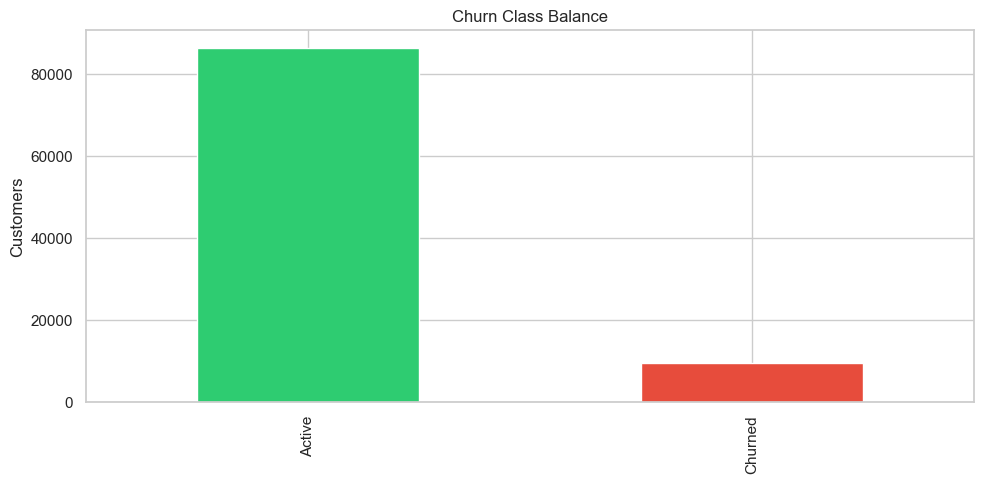

Churn rate: 89.9%


In [8]:
churn_counts = customer_features["is_churned"].value_counts()
churn_counts.index = ["Active", "Churned"]
churn_counts.plot(kind="bar", title="Churn Class Balance", ylabel="Customers", color=["#2ecc71", "#e74c3c"])
plt.tight_layout()
plt.show()

print(f"Churn rate: {customer_features['is_churned'].mean():.1%}")

## 4. Model Training

In [9]:
X = customer_features[feature_cols]
y = customer_features[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} customers")
print(f"Test set:     {len(X_test):,} customers")

Training set: 76,876 customers
Test set:     19,220 customers


In [10]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Accuracy: 1.000


## 5. Evaluation

In [11]:
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      1933
     Churned       1.00      1.00      1.00     17287

    accuracy                           1.00     19220
   macro avg       1.00      1.00      1.00     19220
weighted avg       1.00      1.00      1.00     19220



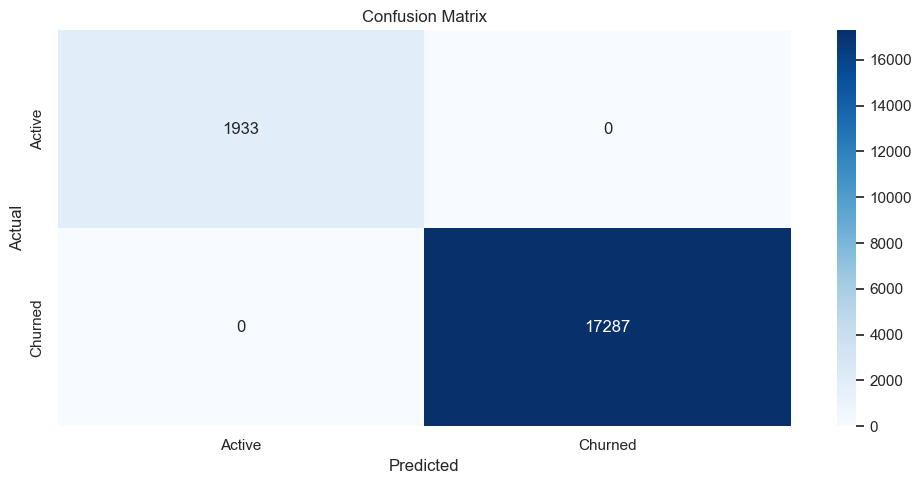

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"],
            yticklabels=["Active", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

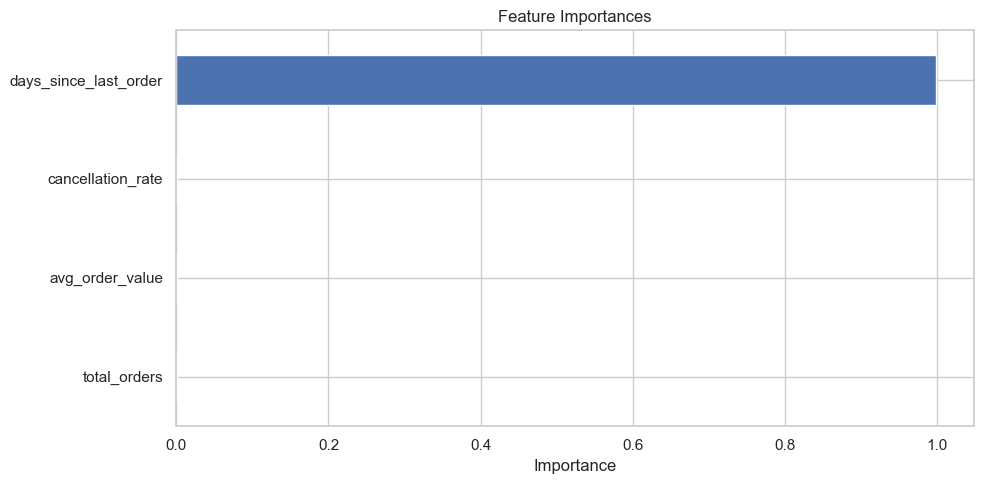

In [13]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind="barh", title="Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 6. Save Model

In [14]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/churn_model.pkl")
print("Model saved to models/churn_model.pkl")

# Quick verification
loaded = joblib.load("../models/churn_model.pkl")
sample = X_test.iloc[:1]
prob = loaded.predict_proba(sample)[0]
print(f"Sample prediction — Active: {prob[0]:.1%}, Churned: {prob[1]:.1%}")

Model saved to models/churn_model.pkl
Sample prediction — Active: 0.0%, Churned: 100.0%


In [15]:
conn.close()
print("Done!")

Done!
